## Navigo Training Demo: Mouse Embryogenesis Subset

This tutorial walks through the complete Navigo training pipeline on a compact 10,000-cell, 10-timepoint subset of the mouse embryogenesis atlas. The small size makes it feasible to train end-to-end in an interactive session while demonstrating the full workflow.

**Steps:**
1. Sample a training subset from the full atlas
2. Train Navigo end-to-end on GPU
3. Review loss curves and per-round EMD scores
4. Validate on held-out intermediate time points

In [1]:
import json, os, subprocess, sys, warnings
from pathlib import Path
import matplotlib.pyplot as plt, numpy as np, pandas as pd, torch
from IPython.display import Image, display
import navigo, navigo.tl
warnings.filterwarnings('ignore')
%config InlineBackend.figure_format = 'retina'
navigo.set_seed(42)

## Configuration

Set your data, checkpoint, and output directories. The training uses the `submission/main_navigo.py` entrypoint on GPU with a compact schedule.

In [2]:
DATA_DIR   = Path("/scratch/users/steorra/analysis/26_yimin/data")
OUTPUT_DIR = Path("/scratch/users/steorra/analysis/26_yimin/Navigo-release/docs/tutorials/outputs")
REPO_ROOT  = Path("/scratch/users/steorra/analysis/26_yimin/Navigo-release")

FULL_DATA   = DATA_DIR / 'interpolation' / 'mouse_embryogenesis_aggregated_full_hvg_4000.h5ad'
output_root = OUTPUT_DIR / 'training_demo'
subset_data = output_root / '00_subset' / 'mouse_embryogenesis_training_subset_10k_10tp.h5ad'

TRAIN_ROUNDS = 3; TRAIN_STEPS = 20; TRAIN_BATCH_SIZE = 16; TRAIN_DEVICE = 'cuda'; SEED = 42
TRAIN_TAG = f'gpu0_bs{TRAIN_BATCH_SIZE}_r{TRAIN_ROUNDS}_s{TRAIN_STEPS}_subset10k'
training_dir = output_root / f'01_training_run_{TRAIN_TAG}'
validation_dir = output_root / f'02_validation_metrics_{TRAIN_TAG}'
figures_dir = output_root / '03_notebook_figures'
for d in [training_dir, validation_dir, figures_dir]:
    d.mkdir(parents=True, exist_ok=True)

print(f'Training: {TRAIN_ROUNDS} rounds x {TRAIN_STEPS} steps, batch={TRAIN_BATCH_SIZE}, device={TRAIN_DEVICE}')

Training: 3 rounds x 20 steps, batch=16, device=cuda


## Step 1: Sample training subset

Stratified sampling of 10,000 cells across 10 uniformly-spaced time points from the full atlas. The result is cached so re-running is instant.

In [3]:
subset_info = navigo.tl.sample_training_subset(
    FULL_DATA, subset_data,
    total_cells=10000, num_timepoints=10, seed=SEED,
)
print(f"Sampled {subset_info['total_cells']} cells across {subset_info['num_timepoints']} time points")

Sampled 10000 cells across 10 time points


## Step 2: Train Navigo

Run the standard Navigo training loop. Each round:
1. Fits the flow matching ODE on the sampled cells
2. Evaluates EMD on training time points
3. Saves a checkpoint

Training progress is shown via tqdm.

In [4]:
train_script = REPO_ROOT / 'submission' / 'main_navigo.py'
checkpoint_path = training_dir / f'checkpoint-{TRAIN_ROUNDS}.pth'
log_path = training_dir / 'training_stdout.log'

if checkpoint_path.exists() and log_path.exists():
    print('Reusing existing training outputs.')
else:
    env = dict(os.environ)
    env['PYTHONPATH'] = str(REPO_ROOT)
    proc = subprocess.run([
        sys.executable, str(train_script),
        '--input_data', str(subset_data),
        '--output_dir', str(training_dir),
        '--rounds', str(TRAIN_ROUNDS),
        '--train_steps', str(TRAIN_STEPS),
        '--batch_size', str(TRAIN_BATCH_SIZE),
        '--save_every', '1',
        '--device', TRAIN_DEVICE,
    ], check=True, cwd=REPO_ROOT, env=env, capture_output=True, text=True)
    log_path.write_text((proc.stdout or '') + '\n' + (proc.stderr or ''))

print(f"Checkpoints: {len(list(training_dir.glob('checkpoint-*.pth')))}")

Reusing existing training outputs.
Checkpoints: 3


## Step 3: Parse training log

Extract per-step loss values and per-round EMD alignment scores from the training log and score JSON files.

In [5]:
loss_df = navigo.tl.parse_training_log(log_path)
print(f"Parsed {len(loss_df)} training steps")
loss_df.tail()

Parsed 60 training steps


,all_loss,all_loss_rectify_s,all_loss_rectify_u,all_loss_rectify,velocity_s_norm,velocity_u_norm,train_step
55,1056.781,929.393,127.388,1056.781,2.469,0.906,56
56,1031.033,907.489,123.545,1031.033,2.428,0.909,57
57,1023.397,901.194,122.203,1023.397,2.388,0.900,58
58,1026.999,902.144,124.855,1026.999,2.355,0.898,59
59,1000.804,879.497,121.308,1000.804,2.295,0.891,60


In [6]:
round_df, final_detail_df = navigo.tl.summarize_round_scores(training_dir)
print(f"Parsed {len(round_df)} rounds")
round_df

Parsed 3 rounds


,round,mean_prediction_emd,mean_baseline_emd,mean_improvement,mean_relative_improvement
0,1,6.568743,6.417941,-0.150802,-0.053664
1,2,5.628500,6.417941,0.789441,0.099307
2,3,5.345367,6.417941,1.072574,0.146576


## Step 4: Visualize training progress

Left: total loss over training steps. Right: mean EMD at each round (lower = better alignment).

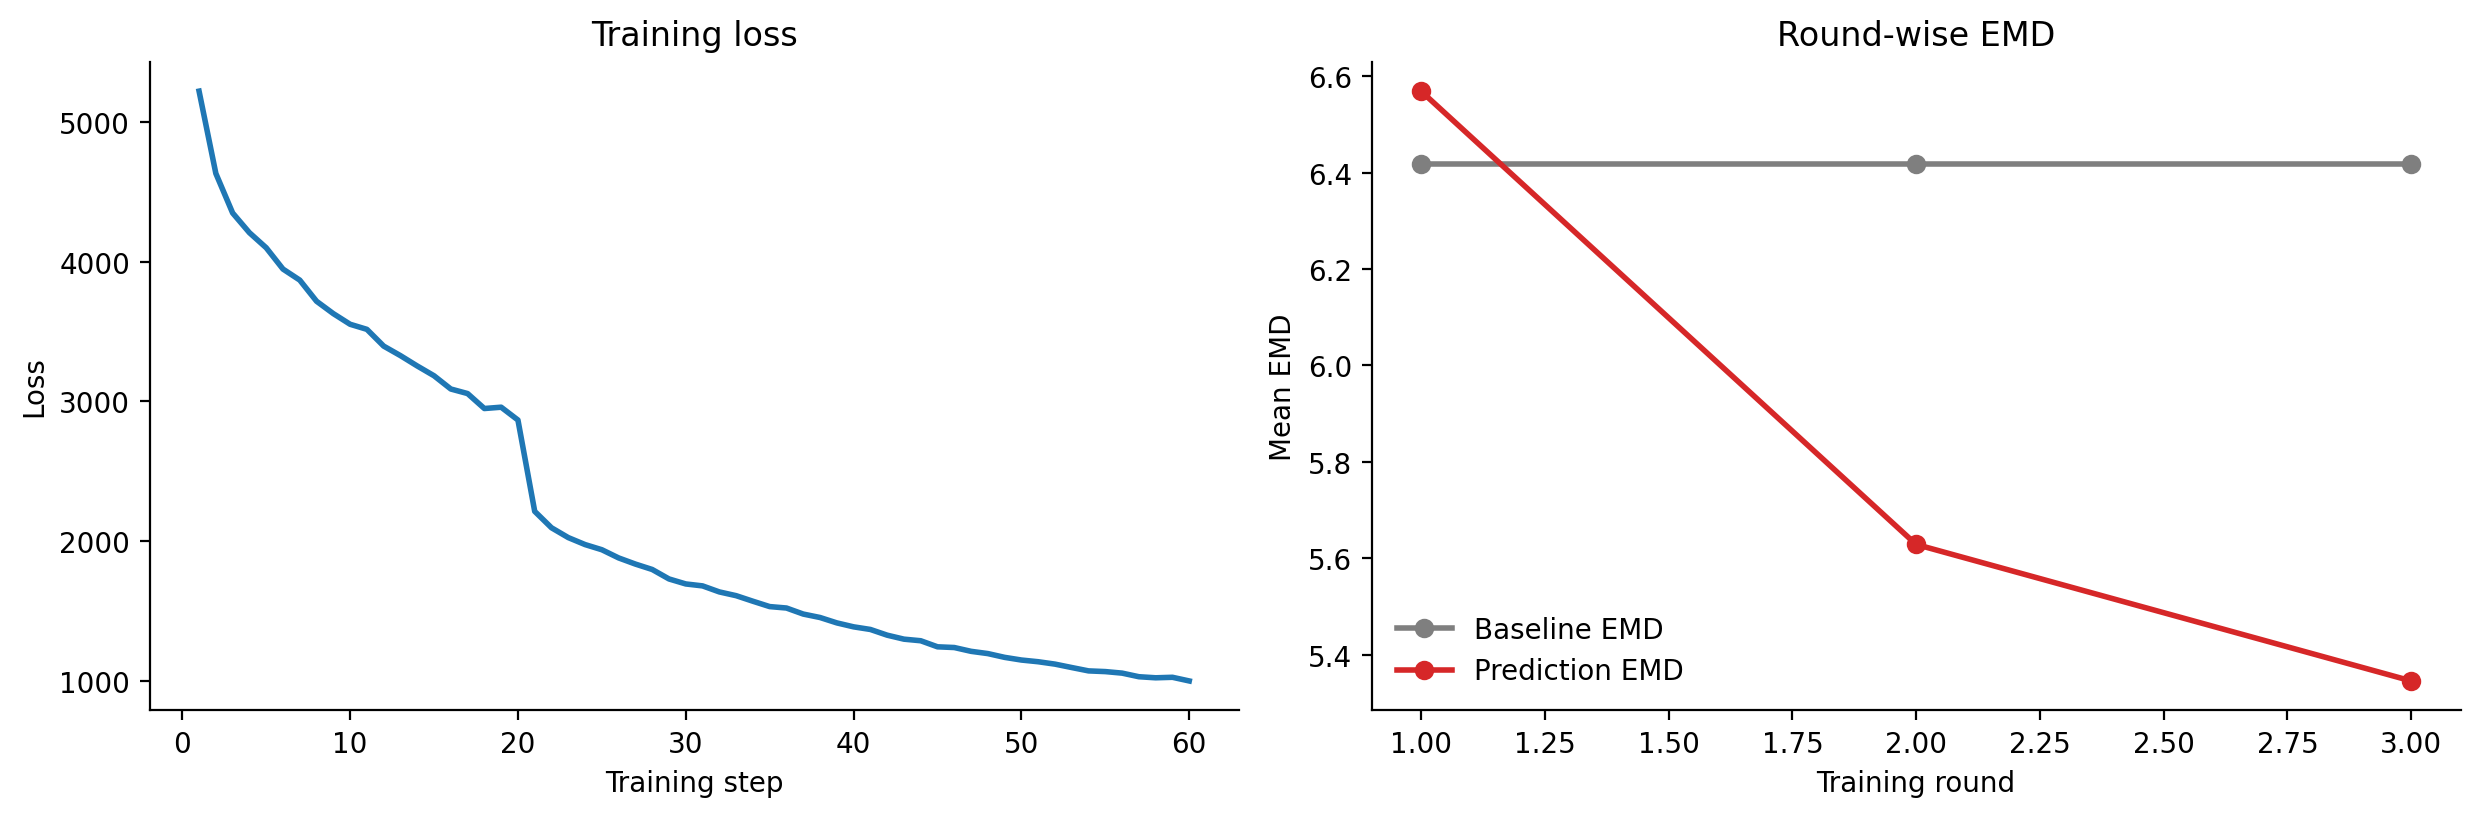

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))

axes[0].plot(loss_df['train_step'], loss_df['all_loss'], color='#1f77b4', lw=2)
axes[0].set_xlabel('Training step'); axes[0].set_ylabel('Loss'); axes[0].set_title('Training loss')
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

axes[1].plot(round_df['round'], round_df['mean_baseline_emd'], 'o-', label='Baseline EMD', color='#7f7f7f', lw=2)
axes[1].plot(round_df['round'], round_df['mean_prediction_emd'], 'o-', label='Prediction EMD', color='#d62728', lw=2)
axes[1].set_xlabel('Training round'); axes[1].set_ylabel('Mean EMD'); axes[1].set_title('Round-wise EMD')
axes[1].legend(frameon=False); axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

plt.tight_layout(); plt.show()

## Step 5: Validate on held-out intermediate time points

Evaluate the final checkpoint on time points that were between training times but not used during training. Compare prediction EMD against start-anchor and end-anchor baselines.

In [8]:
val_result = navigo.tl.validate_training(
    subset_data, FULL_DATA, checkpoint_path, validation_dir,
    seed=SEED,
)
print(f"Mean prediction EMD: {val_result['summary']['mean_prediction_emd']:.4f}")
print(f"Mean start baseline: {val_result['summary']['mean_start_emd']:.4f}")
val_result['metrics']

Mean prediction EMD: 5.3722
Mean start baseline: 5.9676


,source_time,target_time,next_train_time,source_day,target_day,next_train_day,start_cells,prediction_cells,ground_truth_cells,end_anchor_cells,start_emd,prediction_emd,end_anchor_emd,prediction_vs_start_improvement,prediction_vs_end_improvement
0,0.0,1.0,4.0,E8.5,E8.75,E9.5,300,300,300,300,10.476104,8.420849,5.494008,2.055254,-2.926841
1,0.0,2.0,4.0,E8.5,E9.0,E9.5,300,300,300,300,9.451131,6.451220,5.483918,2.999911,-0.967302
2,0.0,3.0,4.0,E8.5,E9.25,E9.5,300,300,300,300,10.531727,6.566162,4.523247,3.965565,-2.042915
3,4.0,5.0,9.0,E9.5,E9.75,E10.75,300,300,300,300,4.739012,4.374040,5.425884,0.364972,1.051845
4,4.0,6.0,9.0,E9.5,E10.0,E10.75,300,300,300,300,5.388108,5.051020,5.583403,0.337088,0.532384
5,4.0,7.0,9.0,E9.5,E10.25,E10.75,300,300,300,300,5.425562,4.483790,4.117977,0.941772,-0.365812
6,4.0,8.0,9.0,E9.5,E10.5,E10.75,300,300,300,300,5.190321,4.396576,4.434594,0.793746,0.038019
7,9.0,10.0,14.0,E10.75,E11.0,E12.0,300,300,300,300,4.643602,4.388004,5.810485,0.255598,1.422482
8,9.0,11.0,14.0,E10.75,E11.25,E12.0,300,300,300,300,5.180452,4.799094,5.477100,0.381357,0.678006
9,9.0,12.0,14.0,E10.75,E11.5,E12.0,300,300,300,300,4.773017,4.484445,5.411970,0.288573,0.927526


## Step 6: Visualize validation metrics

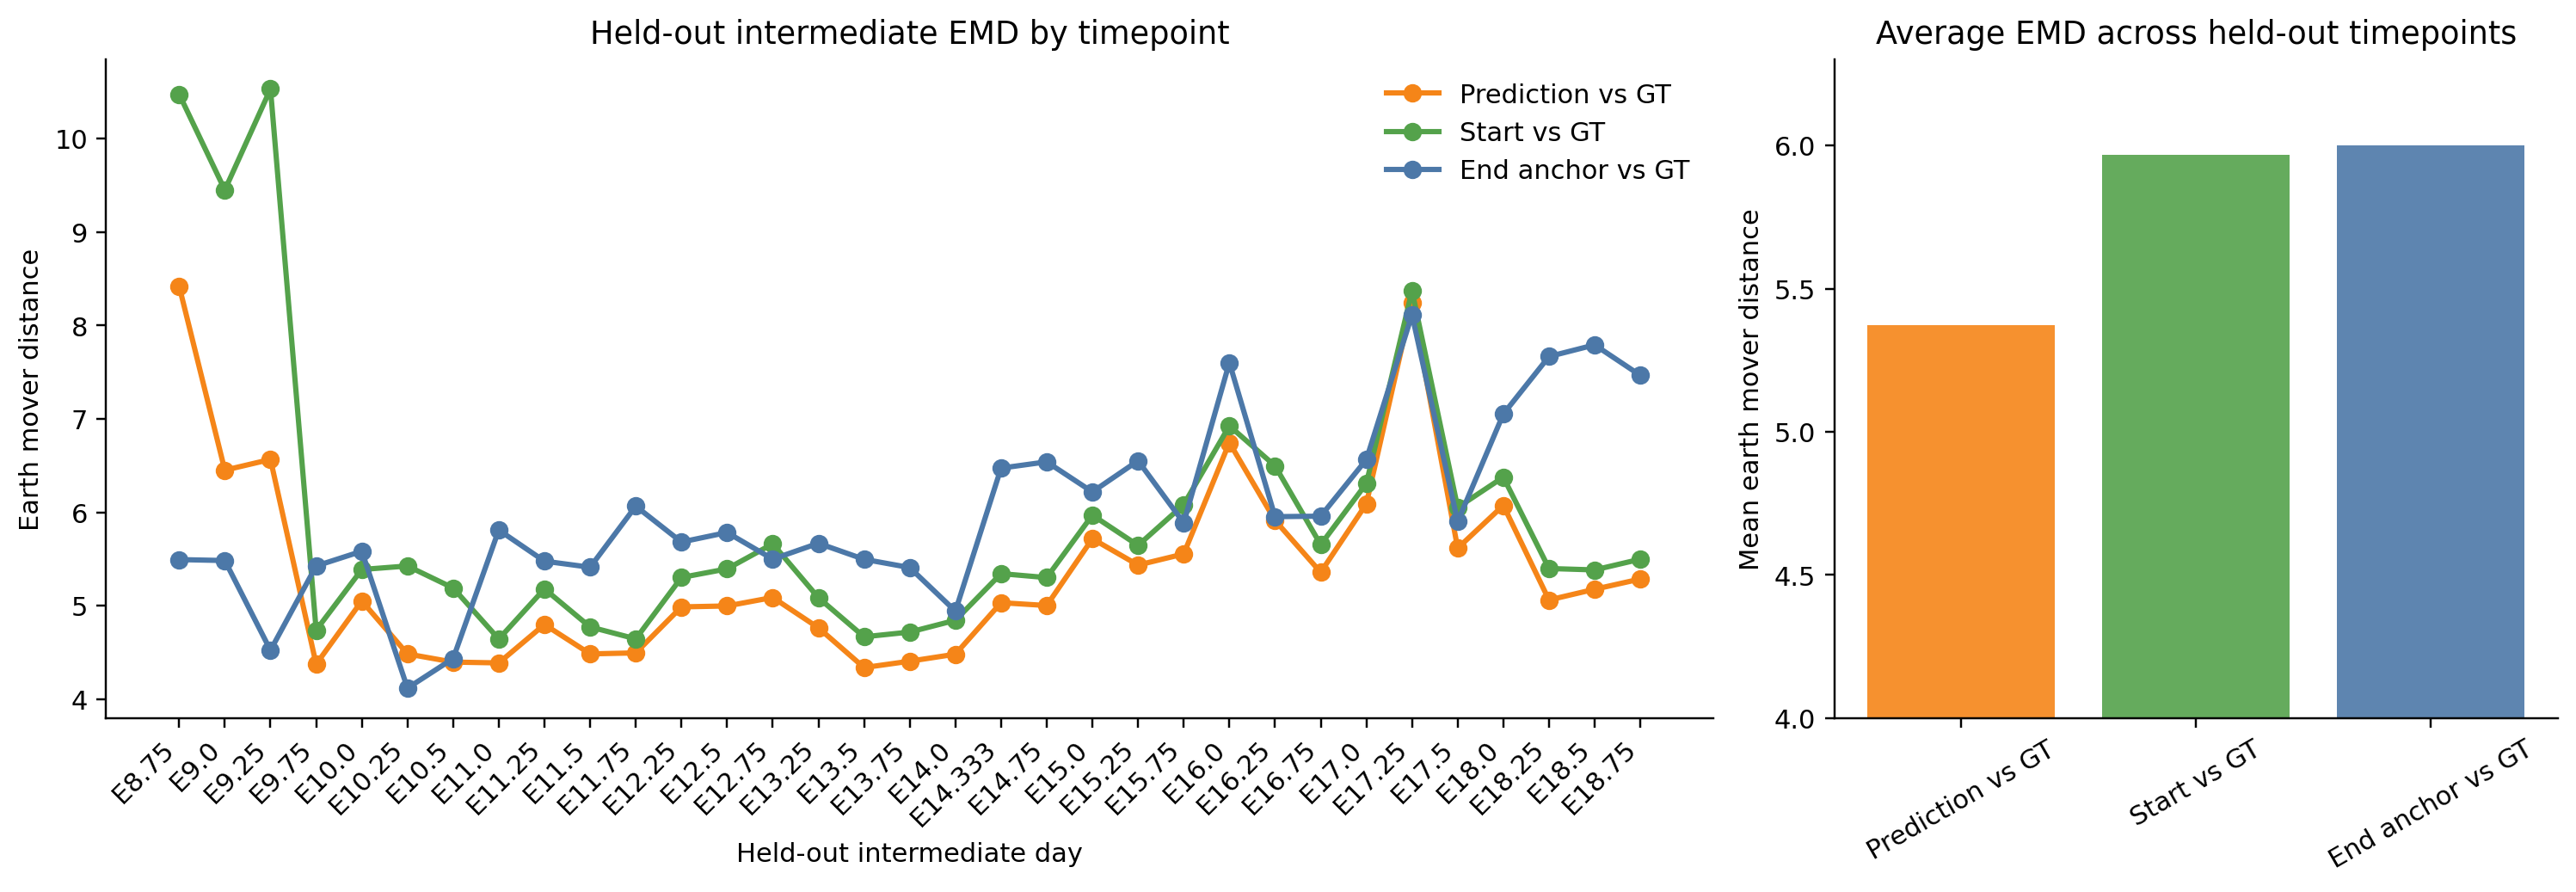

In [9]:
val_png = validation_dir / 'heldout_intermediate_metrics.png'
if val_png.exists():
    display(Image(filename=str(val_png)))